# 02 - Training FCNN (Unimodal - Facial Landmark)

**Tujuan:** Melatih model FCNN untuk pengenalan emosi menggunakan fitur geometris dari facial landmark (68 titik x 2 koordinat = 136 fitur).

**Menjawab RQ2:** *Bagaimana performa model unimodal FCNN dalam pengenalan emosi mahasiswa pada konteks pembelajaran pemrograman menggunakan fitur geometris dari facial landmark?*

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionFCNN
from training.utils import (
    EmotionLandmarkDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "fcnn"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 128
EPOCHS = 100
LR = 0.0001
PATIENCE = 20
NUM_CLASSES = 7

EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/fcnn


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=128):
    """Load train/val/test dataloaders."""
    train_ds = EmotionLandmarkDataset(
        dataset_dir / "X_train_landmarks.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionLandmarkDataset(
        dataset_dir / "X_val_landmarks.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionLandmarkDataset(
        dataset_dir / "X_test_landmarks.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 48
     fearful: 8
   disgusted: 19
   surprised: 70


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b1_baseline.pth")
)

Model parameters: 597,767
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.9482     0.2214     1.7732    0.7138   0.1228   0.000100  (0.9s)


     2      1.5989     0.5296     1.5685    0.7547   0.1266   0.000100  (0.7s)


     3      1.3185     0.7156     1.2418    0.9131   0.1432   0.000100  (0.6s)


     4      1.1057     0.7776     1.2024    0.8450   0.1418   0.000100  (0.6s)


...

    59      0.4623     0.8436     0.3485    0.9395   0.2478   0.000050  (0.6s)


    60      0.4611     0.8429     0.3517    0.9361   0.2642   0.000050  (0.6s)


    61      0.4647     0.8426     0.3821    0.9327   0.2721   0.000050  (0.6s)


    62      0.4543     0.8410     0.3533    0.9336   0.2397   0.000025  (0.6s)


    63      0.4639     0.8412     0.3623    0.9353   0.2644   0.000025  (0.6s)

Early stopping at epoch 63. Best epoch: 43 (val_f1=0.2735)

Best: epoch 43, val_acc=0.9370, val_f1=0.2735
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/fcnn/fcnn_b1_baseline.pth


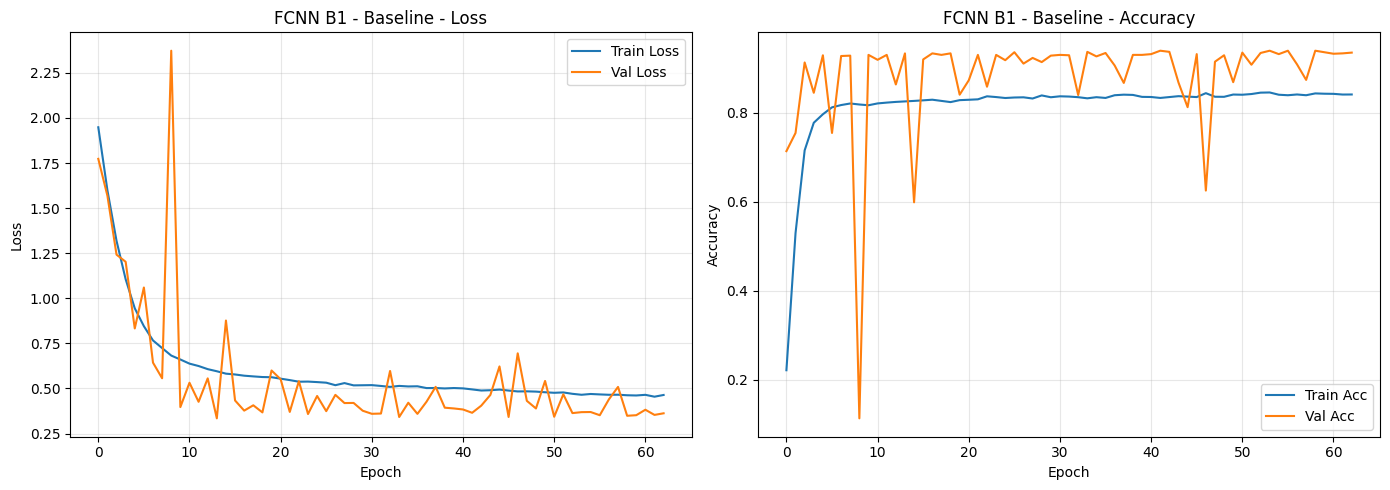

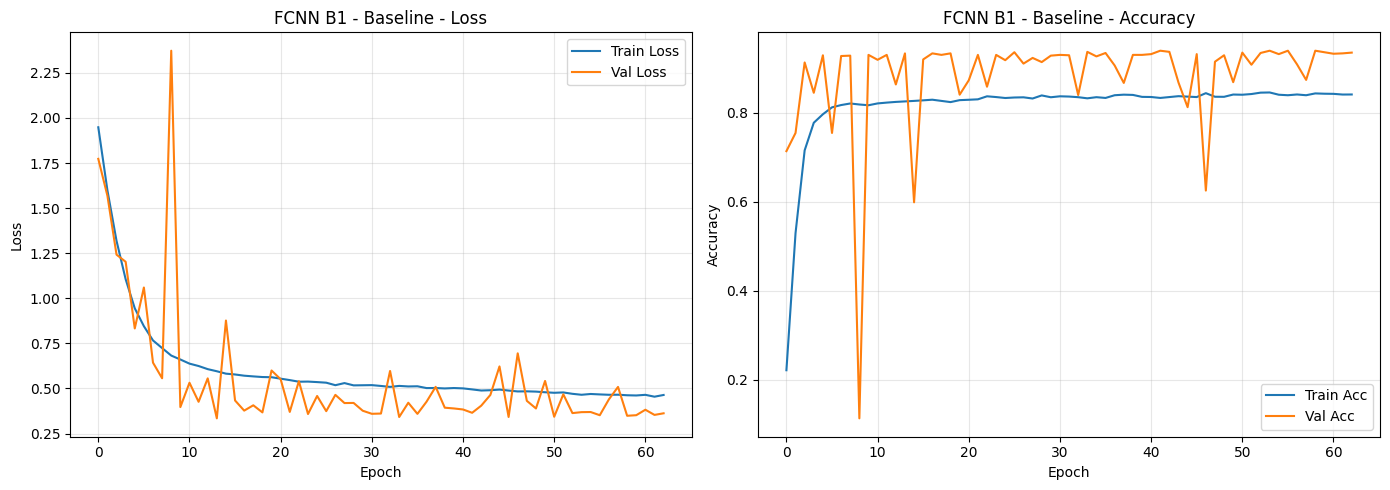

In [5]:
plot_training_history(history_b1, "FCNN B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.2340
Test Accuracy: 0.9583
Test Macro F1: 0.2343
Test Weighted F1: 0.9524

Classification Report:


              precision    recall  f1-score   support

     neutral       0.97      0.99      0.98      1588
       happy       0.15      0.30      0.20        10
         sad       0.61      0.37      0.46        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.96      1656
   macro avg       0.25      0.24      0.23      1656
weighted avg       0.95      0.96      0.95      1656



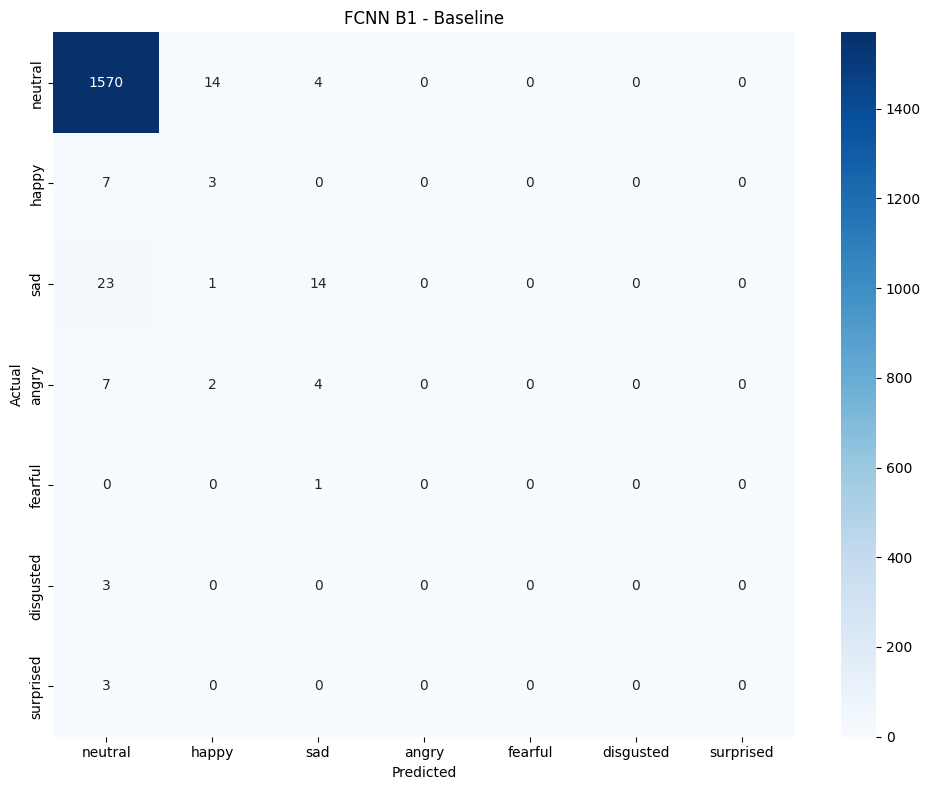

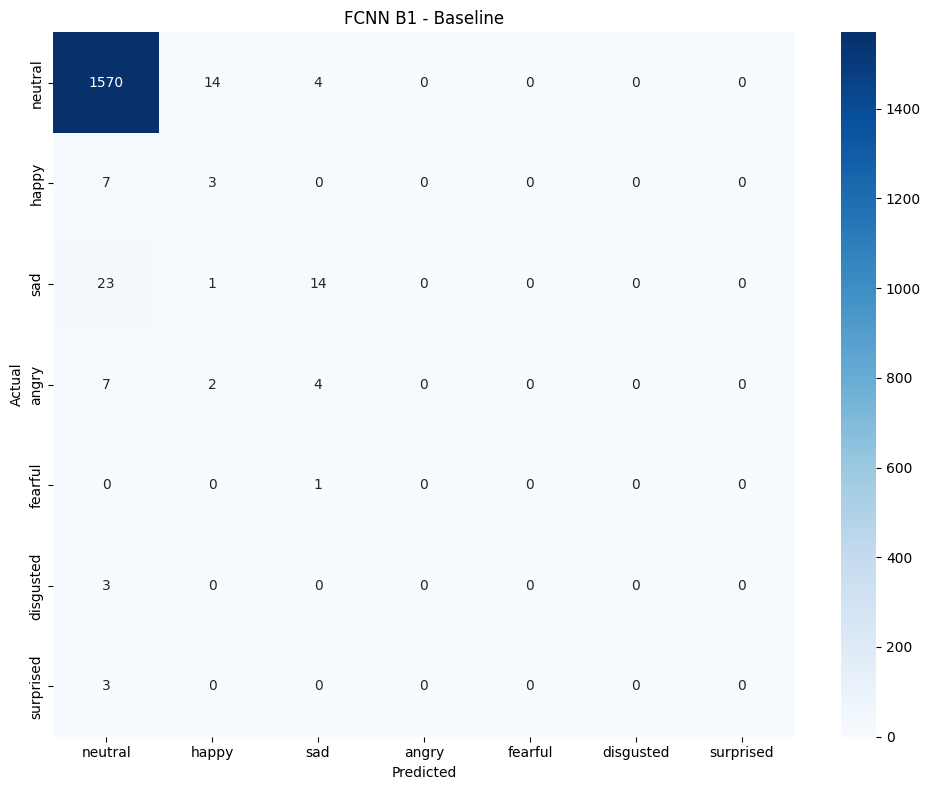

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fcnn")
plot_confusion_matrix(results_b1["confusion_matrix"], "FCNN B1 - Baseline")

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b2_weighted.pth")
)

Class weights: tensor([  1.0000,   1.8865,   2.5717,  21.2542, 125.0103,  52.9257,  14.7340],
       device='cuda:0')

Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.9736     0.1959     1.8500    0.4361   0.0960   0.000100  (0.6s)


     2      1.8561     0.4101     1.7567    0.5383   0.1137   0.000100  (0.6s)


     3      1.7603     0.5933     1.6882    0.7717   0.1360   0.000100  (0.6s)


     4      1.7060     0.6837     1.6093    0.8075   0.1338   0.000100  (0.6s)


...

    56      1.1373     0.7790     1.0025    0.9003   0.2470   0.000025  (0.6s)


    57      1.1249     0.7738     0.9922    0.9020   0.2441   0.000025  (0.6s)


    58      1.1057     0.7752     0.9779    0.9063   0.2500   0.000025  (0.5s)


    59      1.0940     0.7745     1.0362    0.9037   0.2374   0.000013  (0.6s)


    60      1.0857     0.7749     0.9968    0.9046   0.2376   0.000013  (0.6s)

Early stopping at epoch 60. Best epoch: 40 (val_f1=0.2644)

Best: epoch 40, val_acc=0.8893, val_f1=0.2644
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/fcnn/fcnn_b2_weighted.pth


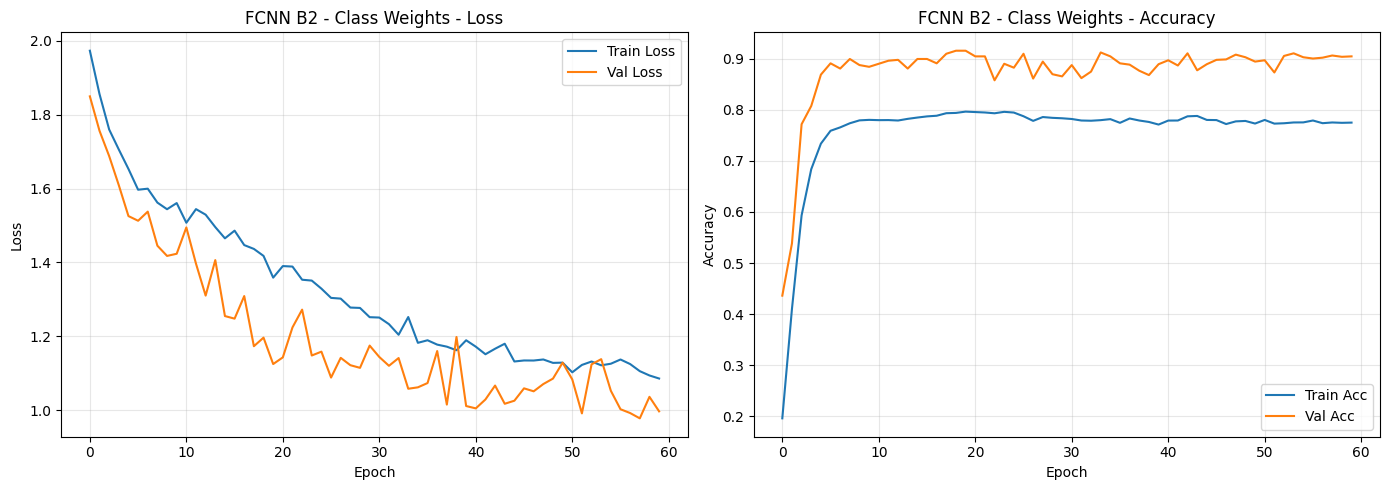

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.9071
Test Accuracy: 0.8913
Test Macro F1: 0.1890
Test Weighted F1: 0.9116

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.93      0.95      1588
       happy       0.12      0.30      0.17        10
         sad       0.67      0.05      0.10        38
       angry       0.00      0.00      0.00        13
     fearful       0.03      1.00      0.05         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.03      0.33      0.06         3

    accuracy                           0.89      1656
   macro avg       0.26      0.37      0.19      1656
weighted avg       0.95      0.89      0.91      1656



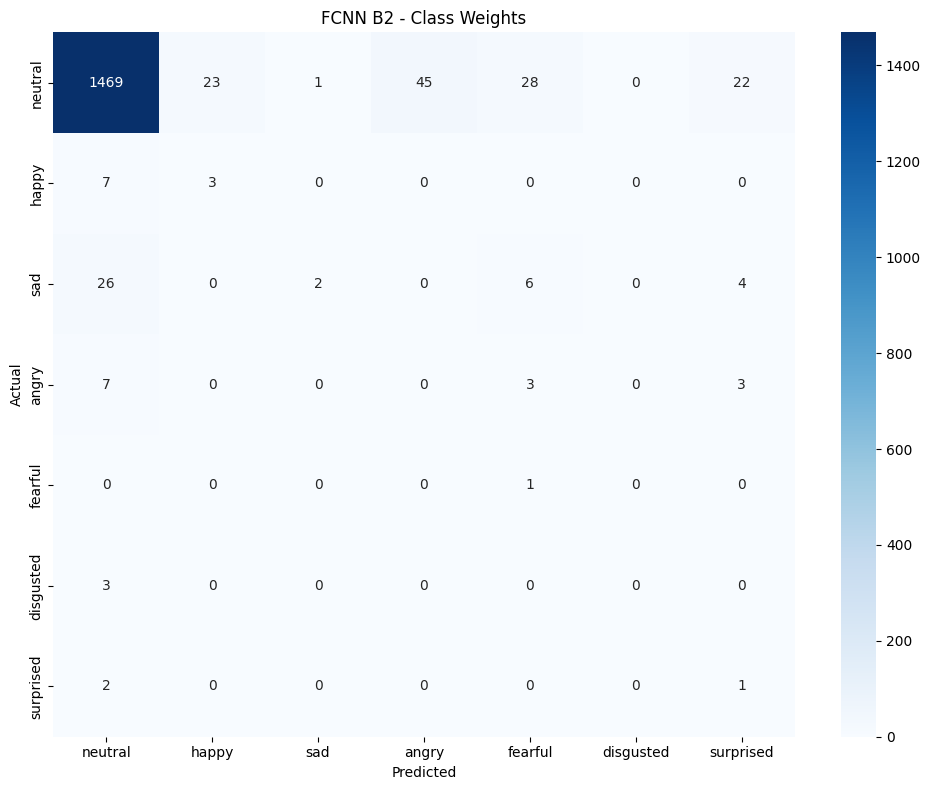

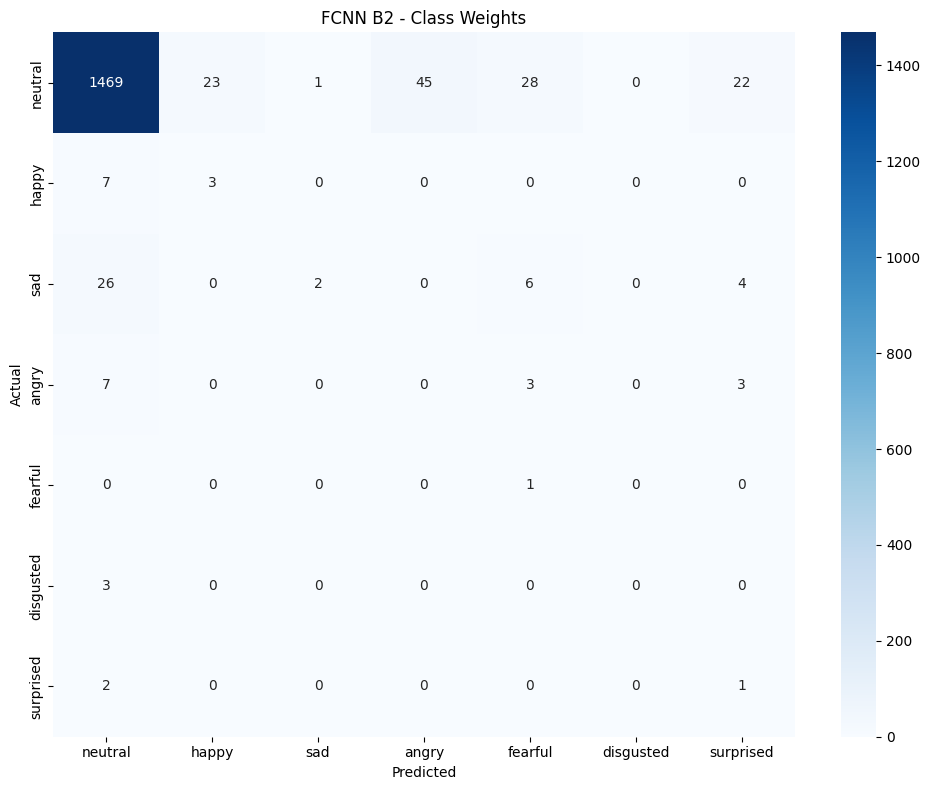

In [8]:
plot_training_history(history_b2, "FCNN B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fcnn")
plot_confusion_matrix(results_b2["confusion_matrix"], "FCNN B2 - Class Weights")

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = EmotionFCNN(input_dim=136, num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fcnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "fcnn_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 7.1514, 7.1514, 7.1514, 7.1514],
       device='cuda:0')

Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      2.0270     0.1569     1.7253    0.8671   0.1327   0.000100  (0.6s)


     2      1.8320     0.4168     1.5402    0.8629   0.1323   0.000100  (0.7s)


     3      1.7294     0.5962     1.4172    0.8680   0.1328   0.000100  (0.6s)


     4      1.6498     0.6754     1.2552    0.9216   0.1370   0.000100  (0.6s)


...

    56      1.0225     0.7646     0.6845    0.9114   0.2469   0.000025  (0.6s)


    57      1.0219     0.7665     0.6689    0.9157   0.2317   0.000025  (0.6s)


    58      1.0104     0.7673     0.6919    0.9174   0.2266   0.000025  (0.6s)


    59      1.0157     0.7611     0.6851    0.9174   0.2549   0.000013  (0.6s)


    60      0.9954     0.7661     0.6755    0.9208   0.2524   0.000013  (0.6s)

Early stopping at epoch 60. Best epoch: 40 (val_f1=0.2716)

Best: epoch 40, val_acc=0.9284, val_f1=0.2716
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/fcnn/fcnn_b3_augmented.pth


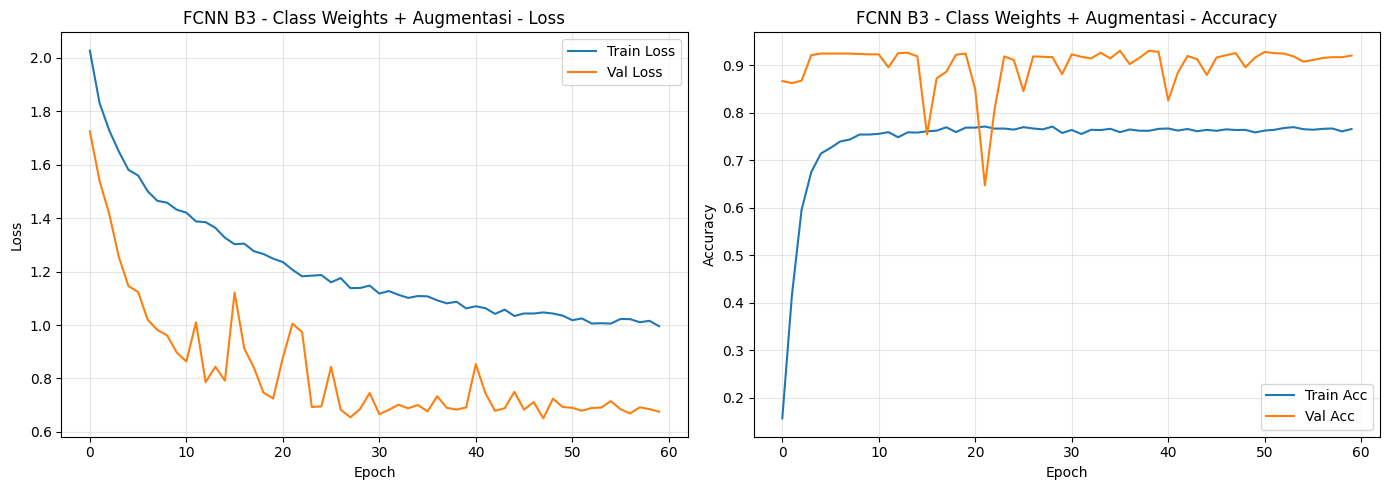

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.5461
Test Accuracy: 0.9227
Test Macro F1: 0.1817
Test Weighted F1: 0.9273

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.96      0.97      1588
       happy       0.12      0.30      0.18        10
         sad       0.00      0.00      0.00        38
       angry       0.00      0.00      0.00        13
     fearful       0.03      1.00      0.05         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.05      0.33      0.08         3

    accuracy                           0.92      1656
   macro avg       0.17      0.37      0.18      1656
weighted avg       0.93      0.92      0.93      1656



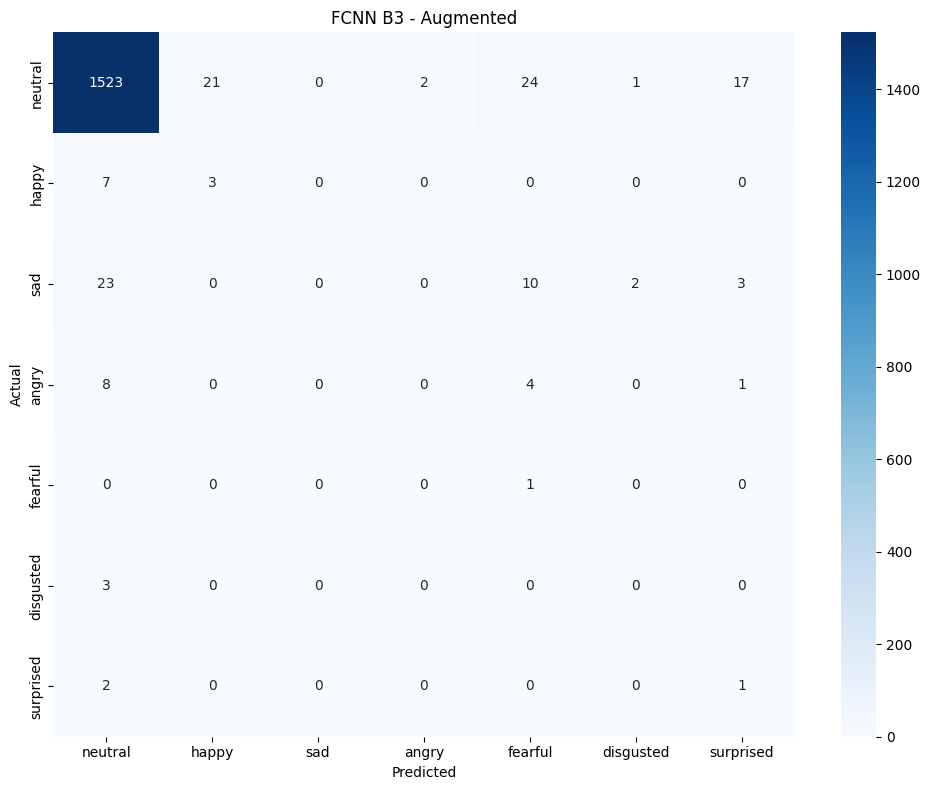

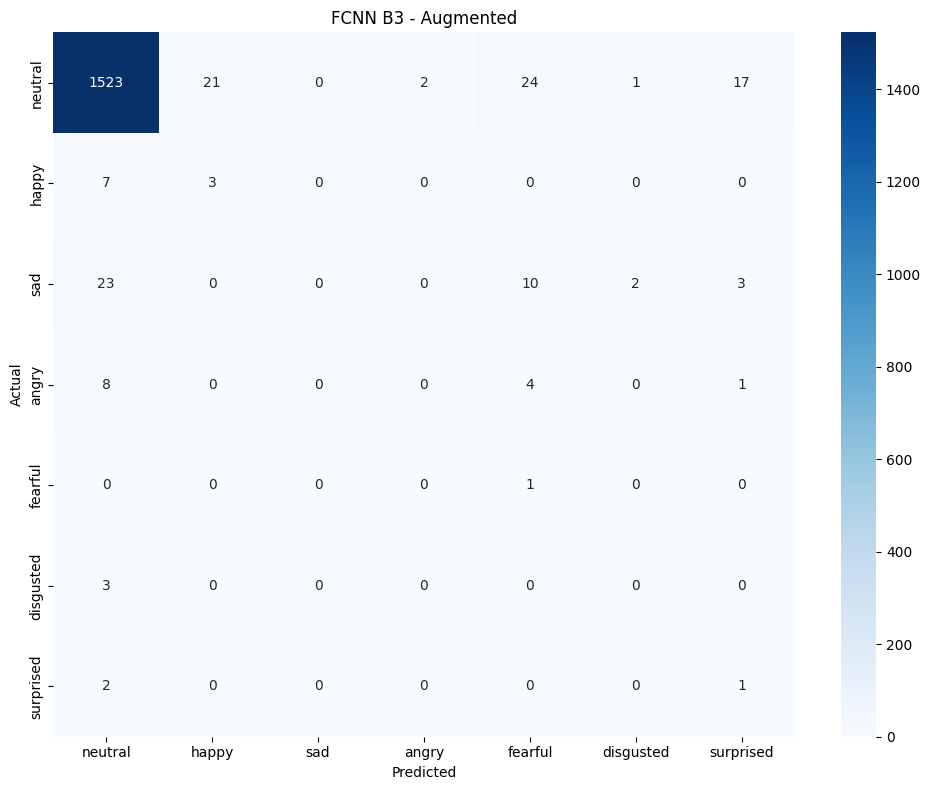

In [10]:
plot_training_history(history_b3, "FCNN B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fcnn")
plot_confusion_matrix(results_b3["confusion_matrix"], "FCNN B3 - Augmented")

## 6. Perbandingan 3 Skenario

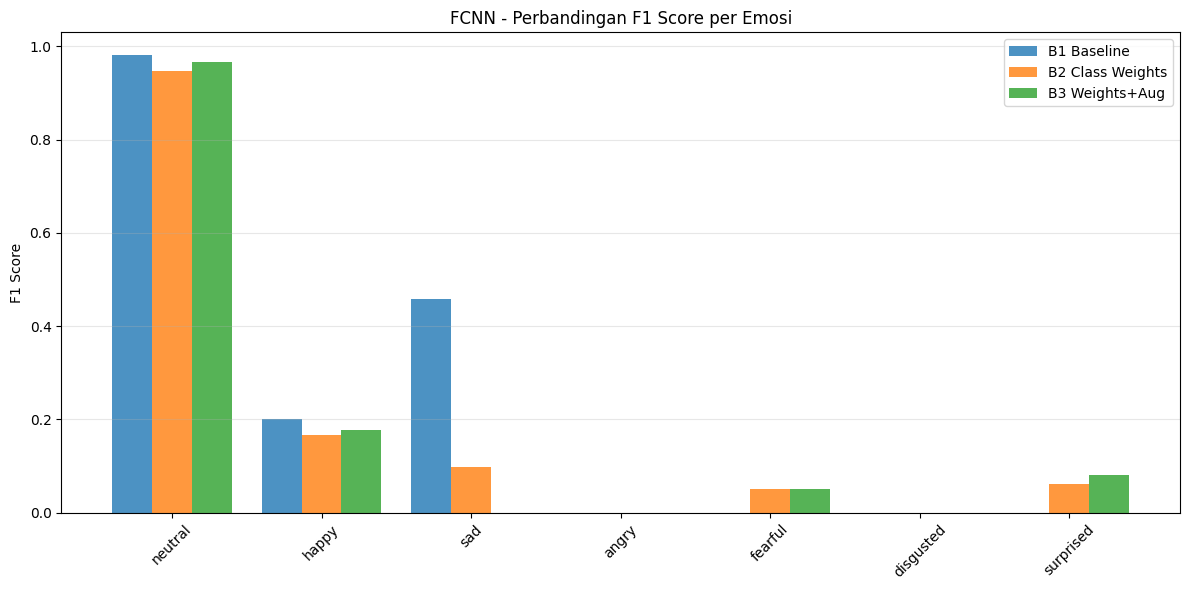

RINGKASAN FCNN - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9583     0.2343       0.9524
B2 Class Weights              0.8913     0.1890       0.9116
B3 Weights+Aug                0.9227     0.1817       0.9273

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/fcnn/fcnn_results.json


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "FCNN - Perbandingan F1 Score per Emosi")

# Summary table
print("=" * 70)
print("RINGKASAN FCNN - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

# Save results
fcnn_results = {}
for name, r in all_results.items():
    fcnn_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "fcnn_results.json", "w") as f:
    json.dump(fcnn_results, f, indent=2)
print(f"\nResults saved to {OUTPUT_DIR / 'fcnn_results.json'}")